In [1]:
import numpy as np
import matplotlib.pyplot as plt

from keras import layers
from keras.datasets import mnist
from keras.models import Model


In [2]:

def preprocess(array):
    """Normalizes the supplied array and reshapes it."""
    array = array.astype("float32") / 255.0
    array = np.reshape(array, (len(array), 28, 28, 1))
    return array


def noise(array):
    """Adds random noise to each image in the supplied array."""
    noise_factor = 0.4
    noisy_array = array + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=array.shape
    )

    return np.clip(noisy_array, 0.0, 1.0)


def display(array1, array2):
    """Displays ten random images from each array."""
    n = 20
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

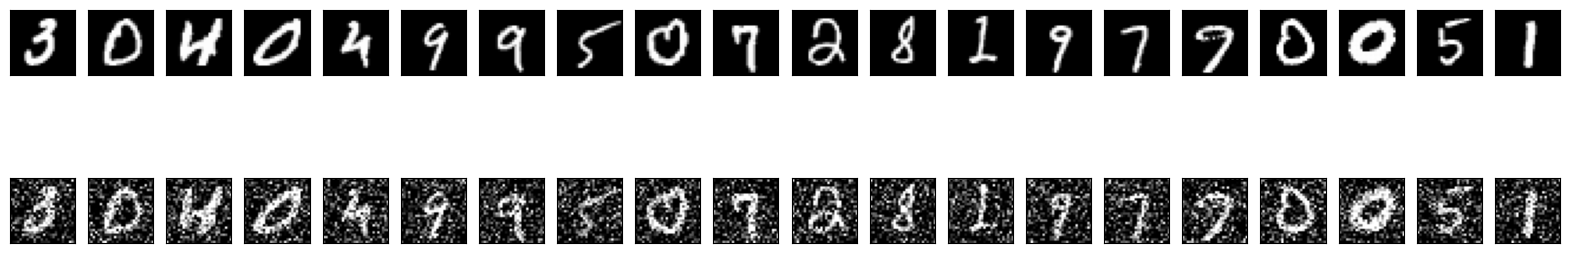

In [3]:
# Since we only need images from the dataset to encode and decode, we
# won't use the labels.
(train_data, _), (test_data, _) = mnist.load_data()

# Normalize and reshape the data
train_data = preprocess(train_data)
test_data = preprocess(test_data)

# Create a copy of the data with added noise
noisy_train_data = noise(train_data)
noisy_test_data = noise(test_data)

# Display the train data and a version of it with added noise
display(train_data, noisy_train_data)

### Build the autoencoder
We are going to use the Functional API to build our convolutional autoencoder.

This autoencoder architecture consists of two main parts: an encoder that compresses the input images and a decoder that reconstructs the original images from the compressed representation. The encoder uses convolutional layers and max pooling to reduce the dimensions, while the decoder uses transposed convolutional layers to restore the original dimensions. The model is designed for tasks like image denoising or dimensionality reduction.

In [4]:
input = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Autoencoder
autoencoder = Model(input, x)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy",  metrics=["accuracy"])
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Now we can train our autoencoder using train_data as both our input data and target. Notice we are setting up the validation data using the same format.

Let's predict on our test dataset and display the original image together with the prediction from our autoencoder.

Notice how the predictions are pretty close to the original images, although not quite the same.

In [5]:
autoencoder.fit(
    x=train_data,
    y=train_data,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(test_data, test_data),
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.8038 - loss: 0.2495 - val_accuracy: 0.8141 - val_loss: 0.0733
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8150 - loss: 0.0727 - val_accuracy: 0.8143 - val_loss: 0.0695
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8159 - loss: 0.0696 - val_accuracy: 0.8144 - val_loss: 0.0680
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8154 - loss: 0.0684 - val_accuracy: 0.8144 - val_loss: 0.0671
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8153 - loss: 0.0675 - val_accuracy: 0.8144 - val_loss: 0.0665
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8156 - loss: 0.0668 - val_accuracy: 0.8144 - val_loss: 0.0659
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8153 - loss: 0.0663 - val_accuracy: 0.8144 - val_loss: 0.0656
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8154 - loss: 0.0659 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


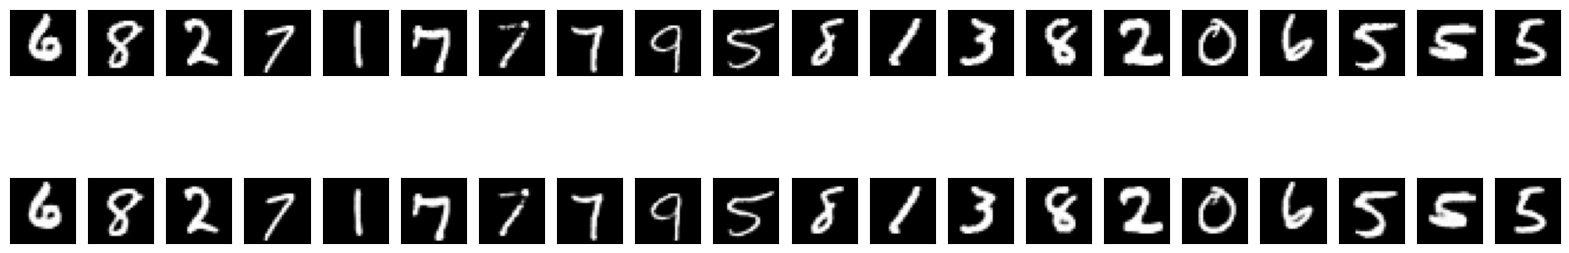

In [6]:
predictions = autoencoder.predict(test_data)
display(test_data, predictions)

Now that we know that our autoencoder works, let's retrain it using the noisy data as our input and the clean data as our target. We want our autoencoder to learn how to denoise the images.

In [7]:
autoencoder.fit(
    x=noisy_train_data,
    y=train_data,
    epochs=100,
    batch_size=128,
    shuffle=True,
    validation_data=(noisy_test_data, test_data),
)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8116 - loss: 0.1136 - val_accuracy: 0.8129 - val_loss: 0.0939
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.8137 - loss: 0.0940 - val_accuracy: 0.8130 - val_loss: 0.0917
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8143 - loss: 0.0919 - val_accuracy: 0.8132 - val_loss: 0.0906
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.8144 - loss: 0.0907 - val_accuracy: 0.8133 - val_loss: 0.0897
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - accuracy: 0.8148 - loss: 0.0899 - val_accuracy: 0.8134 - val_loss: 0.0891
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 178s 334ms/step - accuracy: 0.8145 - loss: 0.0893 - val_accuracy: 0.8133 - val_loss: 0.0885
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 131s 278ms/step - accuracy: 0.8144 - loss: 0.0890 - val_accuracy: 0.8134 - val_loss: 0.0881
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 148s 316ms/step - accuracy: 0.8144 - 

Let's now predict on the noisy data and display the results of our autoencoder.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


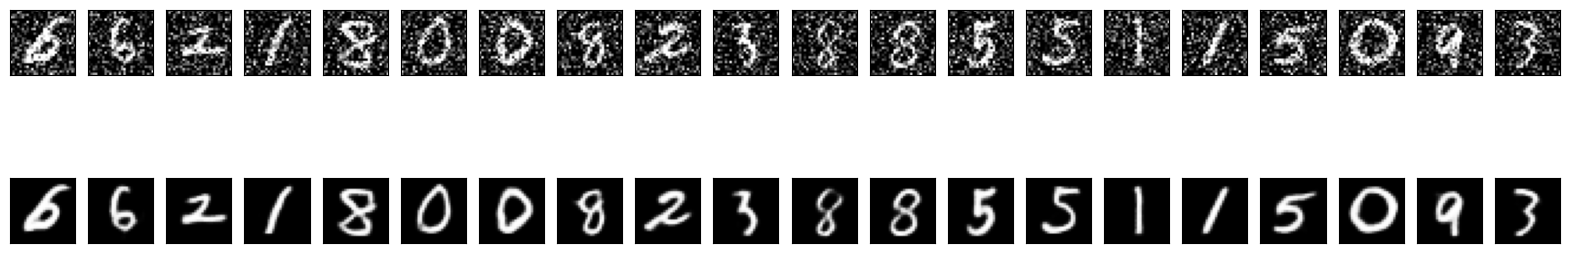

In [8]:
predictions = autoencoder.predict(noisy_test_data)
display(noisy_test_data, predictions)

In [9]:
autoencoder.save("DenoisingAutoencoder.keras")